# Problem 1: Anti-derivative (data-informed)

## Problem Description

Consider a 1D initial value problem

$$\frac{du}{dx} = a(x), \quad x \in [0, 1],$$

subject to an initial condition $u(0) = 0$. The anti-derivative operator $G$ over $[0, 1]$ given by

$$G: \quad a(x) \mapsto G(a)(x) := \int_0^x a(t)\,dt, \quad x \in [0, 1].$$

You're going to setup a DeepONet to learn the operator $G$. In this case, the $a$ will be the input of branch net and the $x$ will be the input of trunk net. As the input of branch net, $a$ is discretized on a fixed uniform grid. They are not necessary to be the same as the query coordinates $x$ at which a DeepONet model is evaluated. For example, you may give the data of $a$ as $\{a(0),\ a(0.5),\ a(1)\}$ but evaluate the output at $\{G(a)(0.1), G(u)(0.8), G(u)(0.9)\}$. This is one of the advantages of DeepONet compared with Fourier neural operator.

## Data Preparation

As data preparation, generate $10{,}000$ different input functions $a$ from a zero mean Gaussian random field (GRF) with an exponential quadratic kernel of a length scale $l = 0.2$. Then obtain the corresponding $10{,}000$ ODE solutions $u$ using an explicit Runge-Kutta method. For each input output pair of $(a, u)$, it is worth noting that only one observation of $u(\cdot)$ is selected. It highlights the flexibility of DeepONet in terms of tackling various data structure.

In [6]:
from pathlib import Path
import yaml
import torch
import torch.nn as nn
import numpy as np

config_path = Path("conf/config.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data_path = Path("physicsnemo_sym_examples_supplemental_materials_v0.0.1/examples/anti_derivative/data/anti_derivative.npy")

raw = np.load(data_path, allow_pickle=True).item()

# Move everything to GPU once — the full dataset is ~4 MB, fits easily
def to_gpu(key: str) -> torch.Tensor:
    return torch.tensor(raw[key], dtype=torch.float32, device=device)

a_train, x_train, u_train = to_gpu("a_train"), to_gpu("x_train"), to_gpu("u_train")
a_test,  x_test,  u_test  = to_gpu("a_test"),  to_gpu("x_test"),  to_gpu("u_test")

Using device: cuda


In [7]:
from src.data_informed import DeepONet, mlp

n_train   = a_train.shape[0]
batch_size = cfg["batch_size"]["train"]

branch_cfg = cfg["arch"]["branch"]
trunk_cfg  = cfg["arch"]["trunk"]
dropout    = cfg["arch"].get("dropout", 0.0)

branch_net = mlp(branch_cfg["n_sensors"], branch_cfg["layer_size"], branch_cfg["nr_layers"], dropout)
trunk_net  = mlp(trunk_cfg["n_dim"],      trunk_cfg["layer_size"],  trunk_cfg["nr_layers"], dropout)
model      = DeepONet(branch_net, trunk_net).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg["training"]["learning_rate"],
    weight_decay=cfg["training"].get("weight_decay", 0.0),
)
gamma     = cfg["scheduler"]["decay_rate"] ** (1.0 / cfg["scheduler"]["decay_steps"])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
loss_fn   = nn.MSELoss()

max_steps    = cfg["training"]["max_steps"]
rec_val_freq = cfg["training"]["rec_validation_freq"]

step = 0
model.train()

DeepONet(
  (branch_net): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): Tanh()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Dropout(p=0.1, inplace=False)
    (11): Linear(in_features=128, out_features=128, bias=True)
  )
  (trunk_net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): Tanh()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Dropout(p=0.1, inplace=False)
    (11): 

In [8]:
train_history: list[tuple[int, float]] = []
val_history:   list[tuple[int, float]] = []

while step < max_steps:
    # Shuffle once per epoch; randperm stays on GPU
    perm = torch.randperm(n_train, device=device)

    for i in range(0, n_train, batch_size):

        if step >= max_steps:
            break

        idx = perm[i : i + batch_size]
        a_b, x_b, u_b = a_train[idx], x_train[idx], u_train[idx]

        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(a_b, x_b), u_b)
        loss.backward()
        optimizer.step()
        scheduler.step()
        step += 1

        train_history.append((step, loss.item()))

        if step % rec_val_freq == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                val_losses = [
                    loss_fn(
                        model(a_test[k * 100 : (k + 1) * 100],
                              x_test[k * 100 : (k + 1) * 100]),
                        u_test[k * 100 : (k + 1) * 100],
                    ).item()
                    for k in range(10)
                ]
            val_mean = float(np.mean(val_losses))
            val_history.append((step, val_mean))
            print(
                f"step {step:>6}/{max_steps}  "
                f"train={loss.item():.4e}  "
                f"val={val_mean:.4e}"
            )
            model.train()


print("Training complete.")

step      1/20000  train=1.8154e-01  val=1.9583e-01
step    500/20000  train=5.0058e-03  val=1.2530e-02
step   1000/20000  train=4.0603e-03  val=1.2321e-02
step   1500/20000  train=3.3944e-03  val=5.3757e-03
step   2000/20000  train=2.8786e-03  val=7.6716e-03
step   2500/20000  train=2.4307e-03  val=7.7197e-03
step   3000/20000  train=2.9115e-03  val=4.2559e-03
step   3500/20000  train=3.3043e-03  val=1.0527e-02
step   4000/20000  train=2.9714e-03  val=1.3411e-02
step   4500/20000  train=3.0517e-03  val=6.5278e-03
step   5000/20000  train=2.2985e-03  val=9.0561e-03
step   5500/20000  train=2.5677e-03  val=5.0866e-03
step   6000/20000  train=2.6361e-03  val=5.3336e-03
step   6500/20000  train=2.4941e-03  val=6.7336e-03
step   7000/20000  train=3.8018e-03  val=5.0887e-03
step   7500/20000  train=3.9930e-03  val=6.8559e-03
step   8000/20000  train=4.1798e-03  val=3.6690e-03
step   8500/20000  train=3.0700e-03  val=4.9074e-03
step   9000/20000  train=2.5960e-03  val=4.5798e-03
step   9500/

In [9]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
checkpoint_path = output_dir / "deeponet.pt"
torch.save(
    {
        "step": step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "cfg": cfg,
    },
    checkpoint_path,
)

model.eval()
with torch.no_grad():
    u_pred = model(a_test, x_test).cpu().numpy().ravel()
u_true = u_test.cpu().numpy().ravel()
train_steps,  train_losses = zip(*train_history)
val_steps,    val_losses   = zip(*val_history)

np.savez(
    output_dir / "history.npz",
    train_steps=train_steps,
    train_losses=train_losses,
    val_steps=val_steps,
    val_losses=val_losses,
    u_pred=u_pred,
    u_true=u_true,
)

print(f"Model saved to {checkpoint_path}")

Training complete. Model saved to outputs/deeponet.pt


## Results

### Training & Validation Loss

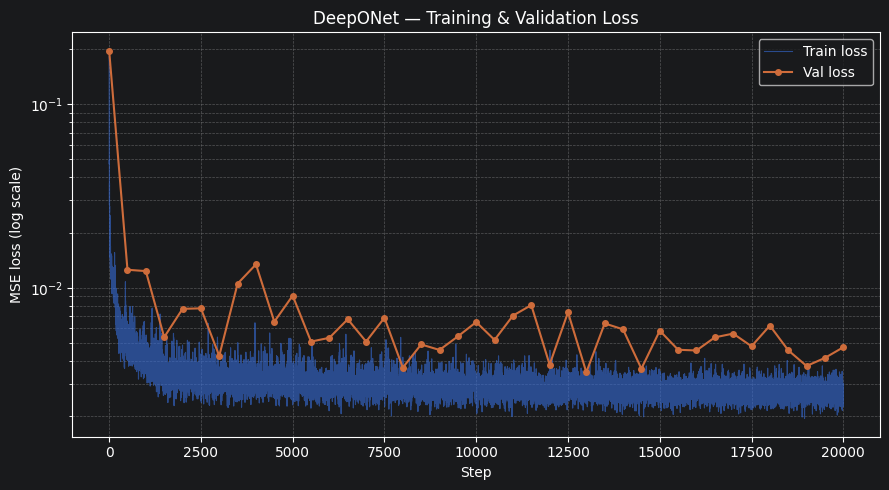

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

history_path = next(
    p / "outputs" / "history.npz"
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "outputs" / "history.npz").exists()
)
h = np.load(history_path)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(h["train_steps"], h["train_losses"], linewidth=0.8, alpha=0.6, label="Train loss")
ax.semilogy(h["val_steps"],   h["val_losses"],   linewidth=1.5, marker="o", markersize=4, label="Val loss")
ax.set_xlabel("Step")
ax.set_ylabel("MSE loss (log scale)")
ax.set_title("DeepONet — Training & Validation Loss")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Predicted vs True (test set)

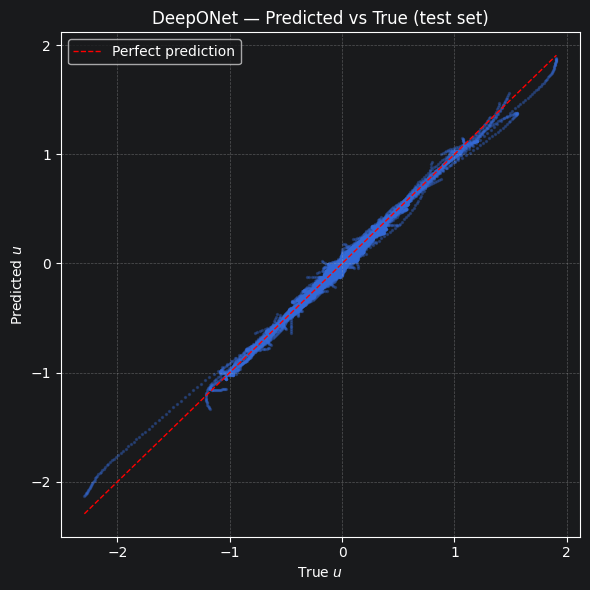

In [11]:
u_pred = h["u_pred"]
u_true = h["u_true"]

lim = (min(u_true.min(), u_pred.min()), max(u_true.max(), u_pred.max()))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(u_true, u_pred, s=2, alpha=0.3, rasterized=True)
ax.plot(lim, lim, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("True $u$")
ax.set_ylabel("Predicted $u$")
ax.set_title("DeepONet — Predicted vs True (test set)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()